In [527]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [528]:
mall_data=pd.read_csv("Mall_Customers.csv")
mall_data.head()
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
mall_data['Genre']=le.fit_transform(mall_data['Genre'])
mall_data.head()
X1=mall_data[["Annual Income (k$)","Spending Score (1-100)"]]
X2=mall_data[["Age","Spending Score (1-100)"]]
X3=mall_data[["Age","Annual Income (k$)","Spending Score (1-100)"]]


In [529]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
# model for Annual income vs spending score
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)
X1=pd.DataFrame(X1_scaled,columns=X1.columns)
kmeans=KMeans(n_clusters=5,init='k-means++',random_state=0)
kmeans.fit(X1)
kmeans.labels_
# print first 10 actual target values and predicted target values using kmeans
print(kmeans.labels_[:10])

[3 4 3 4 3 4 3 4 3 4]


In [530]:
print(kmeans.cluster_centers_)

[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]
 [-1.32954532  1.13217788]]


In [531]:
X1["clusters"]=kmeans.labels_
print(X1.head())

   Annual Income (k$)  Spending Score (1-100)  clusters
0           -1.738999               -0.434801         3
1           -1.738999                1.195704         4
2           -1.700830               -1.715913         3
3           -1.700830                1.040418         4
4           -1.662660               -0.395980         3


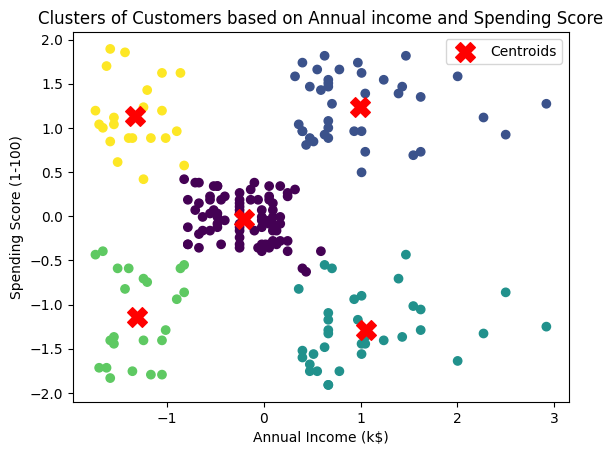

In [532]:
import matplotlib.pyplot as plt
# visualize clusters with there centeroid
plt.scatter(X1.iloc[:, 0],X1.iloc[:, 1], c=kmeans.labels_, cmap="viridis")
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    color="red",
    label="Centroids"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Clusters of Customers based on Annual income and Spending Score")
plt.legend()
plt.show()

In [533]:
from sklearn.metrics import silhouette_score
# check silhouette score for different k vallues
for i in range(2,10):
   kmeans=KMeans(n_clusters=i,random_state=0,n_init="auto")
   kmeans.fit(X1)
   score = silhouette_score(X1.iloc[:,:-1], kmeans.labels_)
   print("Silhouette Score for",i,"clusters is:", score)

Silhouette Score for 2 clusters is: 0.2674789299590746
Silhouette Score for 3 clusters is: 0.37888712497194194
Silhouette Score for 4 clusters is: 0.4561928966487157
Silhouette Score for 5 clusters is: 0.44036758664489883
Silhouette Score for 6 clusters is: 0.5398800926790663
Silhouette Score for 7 clusters is: 0.5159555056080748
Silhouette Score for 8 clusters is: 0.5049839291510378
Silhouette Score for 9 clusters is: 0.4498623954715255


In [534]:
import matplotlib.pyplot as plt

wcss = []  # Within-Cluster Sum of Squares (Inertia)

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init="auto"
    )

    kmeans.fit(X1)
    wcss.append(kmeans.inertia_)

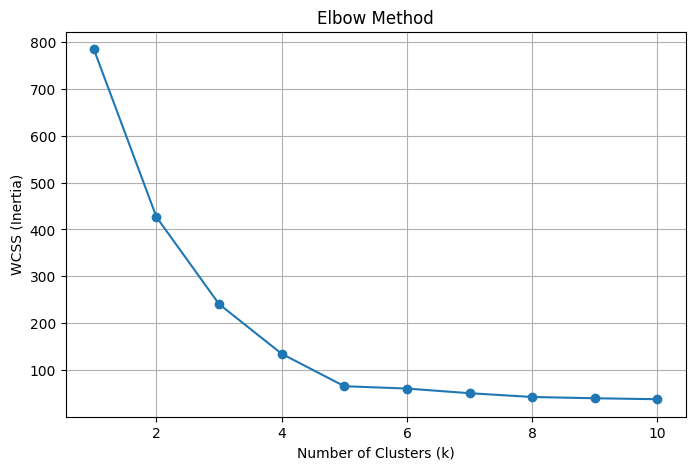

In [535]:
plt.figure(figsize=(8, 5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")

plt.grid(True)
plt.show()

In [536]:
# model for Age vs spending score
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)
X2=pd.DataFrame(X2_scaled,columns=X2.columns)
kmeans=KMeans(n_clusters=4,init='k-means++',random_state=0)
kmeans.fit(X2)
kmeans.labels_
# print first 10 actual target values and predicted target values using kmeans
print(kmeans.labels_[:10])

[3 1 3 1 3 1 2 1 2 1]


In [537]:
X2["clusters"]=kmeans.labels_
print(X2.head())

        Age  Spending Score (1-100)  clusters
0 -1.424569               -0.434801         3
1 -1.281035                1.195704         1
2 -1.352802               -1.715913         3
3 -1.137502                1.040418         1
4 -0.563369               -0.395980         3


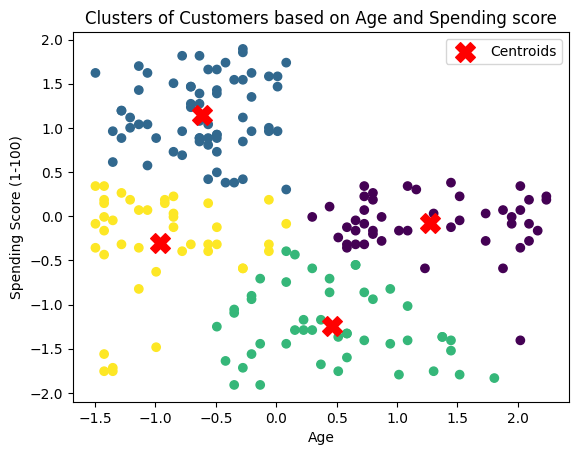

In [538]:
import matplotlib.pyplot as plt
# visualize clusters with there centeroid
plt.scatter(X2.iloc[:, 0],X2.iloc[:, 1], c=kmeans.labels_, cmap="viridis")
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    color="red",
    label="Centroids"
)

plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.title("Clusters of Customers based on Age and Spending score")
plt.legend()
plt.show()

In [539]:
from sklearn.metrics import silhouette_score
# check silhouette score for different k vallues
for i in range(2,10):
   kmeans=KMeans(n_clusters=i,random_state=0,n_init="auto")
   kmeans.fit(X2)
   score = silhouette_score(X2.iloc[:,:-1], kmeans.labels_)
   print("Silhouette Score for",i,"clusters is:", score)

Silhouette Score for 2 clusters is: 0.4413928325233013
Silhouette Score for 3 clusters is: 0.3809432221145262
Silhouette Score for 4 clusters is: 0.43114055026544196
Silhouette Score for 5 clusters is: 0.41862109300238776
Silhouette Score for 6 clusters is: 0.4199028624082712
Silhouette Score for 7 clusters is: 0.4258643921074844
Silhouette Score for 8 clusters is: 0.37362177264183133
Silhouette Score for 9 clusters is: 0.3843491374585362


In [540]:
import matplotlib.pyplot as plt

wcss = []  # Within-Cluster Sum of Squares (Inertia)

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init="auto"
    )

    kmeans.fit(X2)
    wcss.append(kmeans.inertia_)

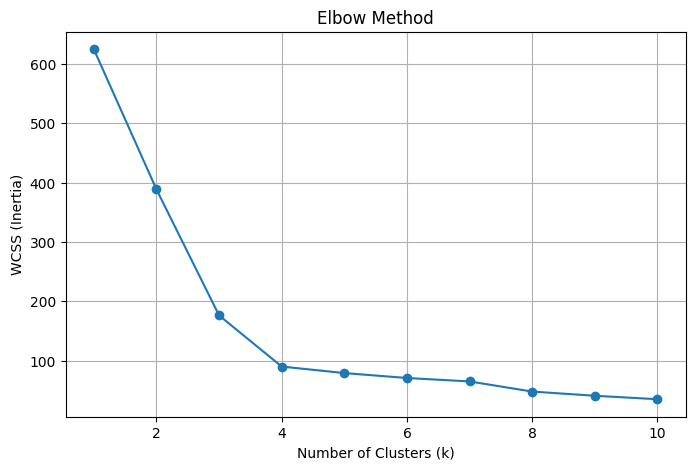

In [541]:
plt.figure(figsize=(8, 5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")

plt.grid(True)
plt.show()

In [542]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
# model for Age and Annual income and spending score
scaller=StandardScaler()
X_scaled=scaller.fit_transform(X3)
X3=pd.DataFrame(X_scaled,columns=X3.columns)
mall_data.head()
kmeans=KMeans(n_clusters=5,init='k-means++',random_state=0)
kmeans.fit(X3)
kmeans.labels_
# print first 10 actual target values and predicted target values using kmeans
print(kmeans.labels_[:10])

[4 4 3 4 4 4 3 4 3 4]


In [543]:
kmeans.cluster_centers_

array([[ 1.20484056, -0.23577338, -0.05236781],
       [ 0.07333084,  0.97494509, -1.19729675],
       [-0.42880597,  0.97484722,  1.21608539],
       [ 0.5310735 , -1.2905084 , -1.23646671],
       [-0.98067852, -0.74305983,  0.46744035]])

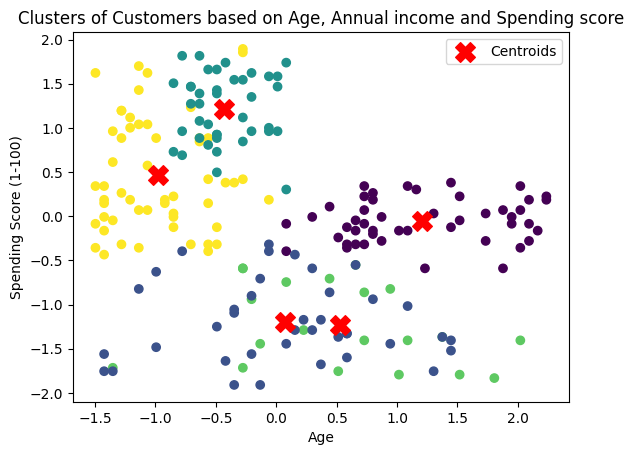

In [544]:
# visualize clusters with there centeroid
plt.scatter(X3.iloc[:,0],X3.iloc[:,2],c=kmeans.labels_,cmap="viridis")
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,2],
    marker="X",
    s=200,
    color="red",
    label="Centroids"
    )
plt.title("Clusters of Customers based on Age, Annual income and Spending score")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [545]:
X3["clusters"]=kmeans.labels_
print(X3.head())

        Age  Annual Income (k$)  Spending Score (1-100)  clusters
0 -1.424569           -1.738999               -0.434801         4
1 -1.281035           -1.738999                1.195704         4
2 -1.352802           -1.700830               -1.715913         3
3 -1.137502           -1.700830                1.040418         4
4 -0.563369           -1.662660               -0.395980         4


In [546]:
from sklearn.metrics import silhouette_score
# check silhouette score for different k vallues
for i in range(2,10):
   kmeans=KMeans(n_clusters=i,random_state=0,n_init="auto")
   kmeans.fit(X3)
   score = silhouette_score(X3.iloc[:,:-1], kmeans.labels_)
   print("Silhouette Score for",i,"clusters is:", score)

Silhouette Score for 2 clusters is: 0.2658860063585319
Silhouette Score for 3 clusters is: 0.3078843781970671
Silhouette Score for 4 clusters is: 0.35466702564906216
Silhouette Score for 5 clusters is: 0.41664341513732767
Silhouette Score for 6 clusters is: 0.41623008126548866
Silhouette Score for 7 clusters is: 0.40331503218006437
Silhouette Score for 8 clusters is: 0.38480235780237876
Silhouette Score for 9 clusters is: 0.39685649482860424


In [547]:
import matplotlib.pyplot as plt

wcss = []  # Within-Cluster Sum of Squares (Inertia)

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init="auto"
    )

    kmeans.fit(X3)
    wcss.append(kmeans.inertia_)

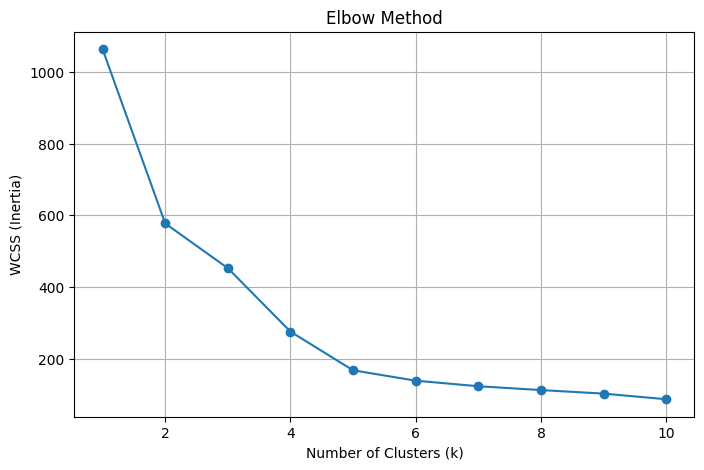

In [548]:
plt.figure(figsize=(8, 5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")

plt.grid(True)
plt.show()